Cs de # 🔍 Minería de Datos — Clase 2: Exploración y Preparación de Datos

**Politécnico Malvinas Argentinas** | Tecnicatura en Ds de Datos e IA | 2026  
**Materia:** Minería de Datos  
**Tipo:** Clase Práctica (Clase 2)  
**Tema:** Análisis Exploratorio de Datos (EDA) con pandas  

---

> **¿Cómo usar este notebook?**  
> Ejecutá cada celda en orden con `Shift + Enter`. Las celdas marcadas con `# TODO:` son las que tenés que completar.

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

| # | Objetivo | Nivel Bloom |
|---|----------|-------------|
| 1 | **Configurar** el entorno de trabajo en Google Colab con las librerías del curso | Aplicar |
| 2 | **Explorar** un dataset real usando los comandos esenciales de pandas | Analizar |
| 3 | **Identificar** problemas de calidad de datos: faltantes, outliers, tipos | Analizar |
| 4 | **Visualizar** distribuciones y relaciones entre variables con seaborn | Evaluar |
| 5 | **Relacionar** los pasos del EDA con las etapas del proceso KDD y CRISP-DM | Evaluar |

---

## 📌 Conexión con la Clase 1

En la Clase 1 aprendimos que el proceso **KDD** tiene 5 etapas:  
`Selección → Preprocesamiento → Transformación → Minería → Evaluación`

Y que **CRISP-DM** propone 6 fases cíclicas:  
`Comprensión del negocio → Comprensión de los datos → Preparación → Modelado → Evaluación → Despliegue`

**¿Dónde estamos hoy?**  
En las etapas 2 y 3 de CRISP-DM: **Comprensión de los datos** y primeros pasos de **Preparación**.  
En KDD: etapas de **Selección** y **Preprocesamiento**.

El **Análisis Exploratorio de Datos (EDA)** es el proceso sistemático de entender un dataset antes de modelar.

---

## ⚙️ Paso 1 — Configuración del Entorno

Google Colab ya viene con las librerías que necesitamos preinstaladas.  
Igualmente vamos a verificar las versiones y agregar la configuración estética.

In [1]:
# Verificar versiones de las librerías principales
#!pip install pandas==3.0
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

print('Versión del notebook:')

print(f'pandas:     {pd.__version__}')
print(f'numpy:      {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn:    {sns.__version__}')
print(f'polars:     {pl.__version__}')

# Configuración estética para todos los gráficos del notebook
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print('\n✅ Entorno listo')

Versión del notebook:
pandas:     2.2.2
numpy:      2.0.2
matplotlib: 3.10.0
seaborn:    0.13.2
polars:     1.35.2

✅ Entorno listo


## 📦 Paso 2 — Carga del Dataset

### El Dataset Titanic

Vamos a trabajar con el dataset del **RMS Titanic**, el transatlántico que se hundió en 1912.  
Es un dataset clásico de Data Science porque:

- ✅ Tiene variables **numéricas** y **categóricas**
- ✅ Contiene **valores faltantes reales** (no artificiales)
- ✅ Tiene un **target claro**: ¿sobrevivió el pasajero? (0 = No, 1 = Sí)
- ✅ Es **pequeño** (~900 filas) pero representativo de problemas reales

> **Contexto CRISP-DM:** Esta es la fase de *Comprensión de los Datos*. Antes de tocar el dataset, ya sabemos nuestro objetivo: predecir supervivencia.

In [2]:
# Carga del dataset desde seaborn (ya disponible en Colab)
df = sns.load_dataset('titanic')

# Vista previa de las primeras 5 filas
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\nPrimeras 5 filas:')
df.head(10)

Dataset cargado: 891 filas × 15 columnas

Primeras 5 filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
# Ver las últimas 5 filas (para detectar si hay patrones al final)
df.tail(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
881,0,3,male,33.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


## 🔎 Paso 3 — Exploración Inicial: Los 5 Comandos Esenciales

Estos 5 comandos son **lo primero que ejecutamos** en cualquier dataset:

| Comando | ¿Qué nos dice? |
|---------|----------------|
| `df.head()` | Primeras filas — vista rápida de la estructura |
| `df.info()` | Tipos de datos, cantidad de no-nulos por columna |
| `df.describe()` | Estadística descriptiva de variables numéricas |
| `df.isnull().sum()` | Cantidad de valores faltantes por columna |
| `df['col'].value_counts()` | Frecuencias de cada categoría |

---

In [4]:
# ─── COMANDO 1: info() ───────────────────────────────────────────────────────
# Muestra: nombre de columna, tipo de dato, cantidad de valores no-nulos
# CLAVE: si non-null count < total filas → hay valores faltantes
print('='*60)
print('df.info()')
print('='*60)
df.info()

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# ─── COMANDO 2: describe() ──────────────────────────────────────────────────
# Estadística descriptiva: count, mean, std, min, 25%, 50% (mediana), 75%, max
# Por defecto solo columnas numéricas
print('Estadística descriptiva — variables numéricas:')
df.describe()

Estadística descriptiva — variables numéricas:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Describe también funciona para variables categóricas
# unique: cantidad de valores únicos | top: valor más frecuente | freq: frecuencia del top
print('Estadística descriptiva — TODAS las variables:')
df.describe(include='all')

Estadística descriptiva — TODAS las variables:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ─── COMANDO 3: isnull().sum() ──────────────────────────────────────────────
# Cuenta cuántos NaN (Not a Number) hay en cada columna
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(1)

# Crear tabla resumen de faltantes
resumen_faltantes = pd.DataFrame({
    'Valores faltantes': missing,
    '% del total': pct_missing
})

# Mostrar solo columnas con faltantes, ordenadas
print('Columnas con valores faltantes:')
resumen_faltantes[resumen_faltantes['Valores faltantes'] > 0].sort_values('% del total', ascending=False)

Columnas con valores faltantes:


,Valores faltantes,% del total
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


In [8]:
# ─── COMANDO 4: value_counts() ──────────────────────────────────────────────
# Frecuencia absoluta y relativa del target (variable objetivo)

print('Distribución de la variable objetivo (survived):')
print(df['survived'].value_counts())
print()
print('Proporción:')
print(df['survived'].value_counts(normalize=True).round(3))
print()
print('→ El dataset tiene un leve desbalance: ~38% sobrevivió, ~62% no.')

Distribución de la variable objetivo (survived):
survived
0    549
1    342
Name: count, dtype: int64

Proporción:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64

→ El dataset tiene un leve desbalance: ~38% sobrevivió, ~62% no.


## 📊 Paso 4 — Tipos de Variables

En cualquier dataset vamos a encontrar dos grandes tipos:

| Tipo | Descripción | Ejemplos en Titanic | Análisis típico |
|------|-------------|---------------------|------------------|
| **Numéricas continuas** | Valores reales con sentido aritmético | `age`, `fare` | Histograma, boxplot, media/mediana |
| **Numéricas discretas** | Enteros contables | `sibsp`, `parch` | value_counts, barplot |
| **Categóricas nominales** | Categorías sin orden | `sex`, `embarked` | Barplot, crosstab |
| **Categóricas ordinales** | Categorías con orden | `pclass` (1 > 2 > 3) | Barplot ordenado |

> ⚠️ **Importante:** El tipo Python (`int`, `float`, `object`) no siempre refleja el tipo estadístico. `pclass` es `int` pero estadísticamente es categórica ordinal.

In [9]:
# Separar variables por tipo de dato Python
numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Variables NUMÉRICAS:')
print(numericas)
print()
print('Variables CATEGÓRICAS:')
print(categoricas)
print()
print('─'*50)
print('Nota: pclass es int pero representa clases (1ª, 2ª, 3ª)')
print('En análisis estadístico la tratamos como ORDINAL')

Variables NUMÉRICAS:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Variables CATEGÓRICAS:
['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']

──────────────────────────────────────────────────
Nota: pclass es int pero representa clases (1ª, 2ª, 3ª)
En análisis estadístico la tratamos como ORDINAL


## 🩹 Paso 5 — Tratamiento de Valores Faltantes

Recordá de la Clase 1: "*Los datos reales raramente están listos para ser usados directamente*".  
Los valores faltantes son uno de los problemas más comunes.

### Estrategias

| Estrategia | Cuándo usarla | pandas |
|-----------|---------------|--------|
| **Eliminar columna** | > 50% faltantes, variable poco importante | `df.drop()` |
| **Eliminar filas** | Pocas filas con faltantes | `df.dropna()` |
| **Imputar con mediana** | Numéricas con outliers | `fillna(mediana)` |
| **Imputar con media** | Numéricas sin outliers | `fillna(media)` |
| **Imputar con moda** | Categóricas | `fillna(moda)` |

> 💡 La `mediana` es más robusta que la `media` cuando hay valores extremos (outliers).

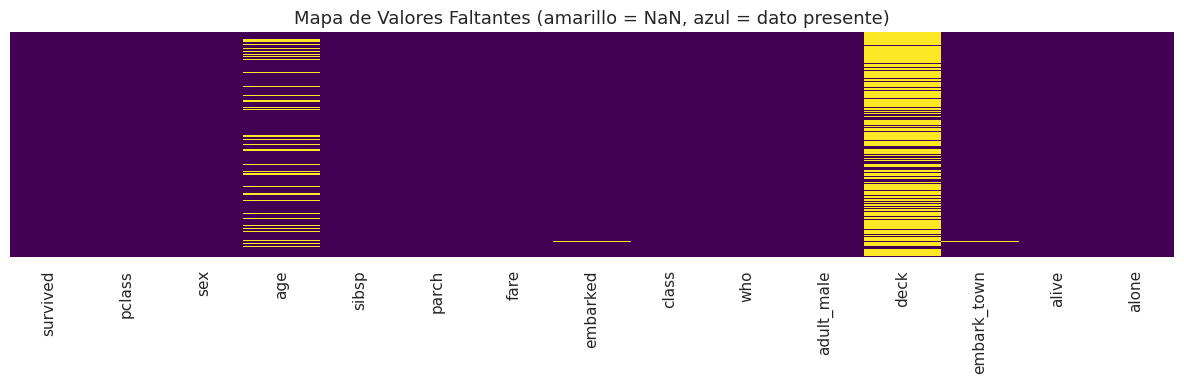

→ Notá que "deck" y "embark_town" tienen muchos faltantes


In [10]:
# Visualizar distribución de faltantes con heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False
)
plt.title('Mapa de Valores Faltantes (amarillo = NaN, azul = dato presente)', fontsize=13)
plt.tight_layout()
plt.show()
print('→ Notá que "deck" y "embark_town" tienen muchos faltantes')

In [11]:
# ─── Tratamiento de faltantes ────────────────────────────────────────────────

# 1. Eliminar columna 'deck' (>77% faltantes, poca información)
df_limpio = df.drop(columns=['deck'])
print(f'Columnas después de eliminar deck: {df_limpio.shape[1]}')

# 2. Imputar 'age' con la mediana (tiene outliers — algunos pasajeros muy viejos)
mediana_edad = df_limpio['age'].median()
df_limpio['age'] = df_limpio['age'].fillna(mediana_edad)
print(f'Mediana de edad usada para imputar: {mediana_edad}')

# 3. Imputar 'embarked' con la moda (solo 2 faltantes)
moda_embarked = df_limpio['embarked'].mode()[0]
df_limpio['embarked'] = df_limpio['embarked'].fillna(moda_embarked)

# Verificar resultado
faltantes_restantes = df_limpio.isnull().sum().sum()
print(f'\nFaltantes restantes en columnas tratadas: {faltantes_restantes}')
print('\nVerificación:')
print(df_limpio[['age', 'embarked']].isnull().sum())

Columnas después de eliminar deck: 14
Mediana de edad usada para imputar: 28.0

Faltantes restantes en columnas tratadas: 2

Verificación:
age         0
embarked    0
dtype: int64


## 🎨 Paso 6 — Visualización Exploratoria

"*Un gráfico bien elegido revela en segundos lo que una tabla tarda minutos en transmitir.*"

| Gráfico | Librería | Cuándo usarlo |
|---------|----------|---------------|
| `histplot` | seaborn | Distribución de una variable numérica |
| `boxplot` | seaborn | Distribución + outliers de numérica |
| `countplot` | seaborn | Frecuencias de una variable categórica |
| `heatmap` | seaborn | Correlaciones entre variables numéricas |
| `scatterplot` | seaborn | Relación entre dos variables numéricas |

---

/tmp/ipykernel_36783/3563756163.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


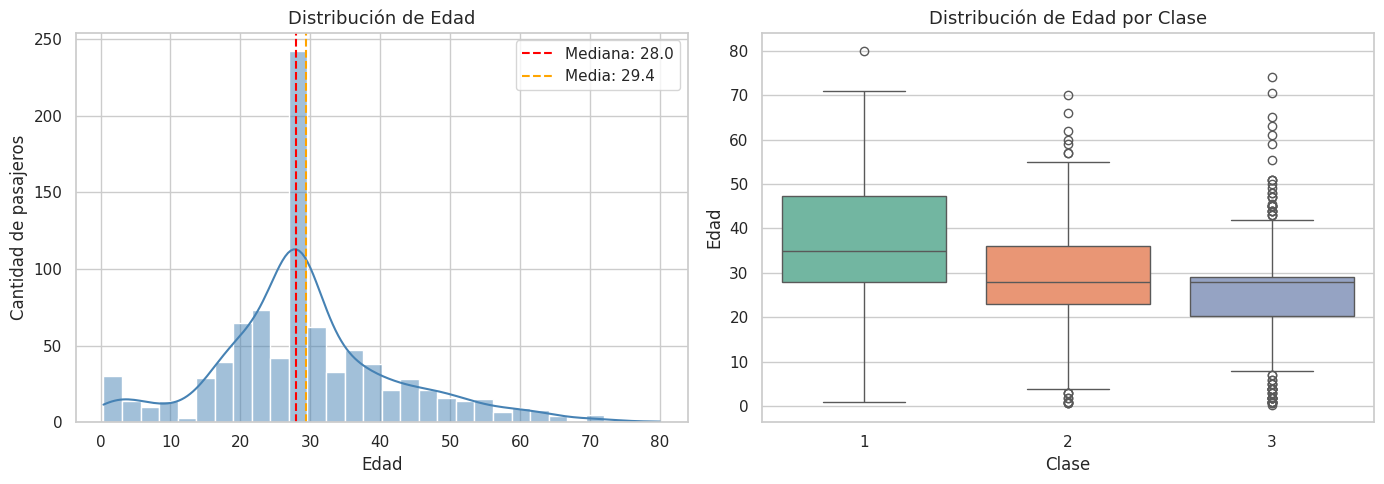

→ Observación: los pasajeros de 1ª clase son en promedio mayores que los de 3ª clase


In [12]:
# ─── Gráfico 1: Distribución de edades ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con curva KDE
sns.histplot(
    df_limpio['age'],
    bins=30,
    kde=True,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Distribución de Edad', fontsize=13)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Cantidad de pasajeros')
axes[0].axvline(df_limpio['age'].median(), color='red', linestyle='--', label=f'Mediana: {df_limpio["age"].median():.1f}')
axes[0].axvline(df_limpio['age'].mean(), color='orange', linestyle='--', label=f'Media: {df_limpio["age"].mean():.1f}')
axes[0].legend()

# Boxplot de edad por clase
sns.boxplot(
    data=df_limpio,
    x='pclass',
    y='age',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Distribución de Edad por Clase', fontsize=13)
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Edad')

plt.tight_layout()
plt.show()
print('→ Observación: los pasajeros de 1ª clase son en promedio mayores que los de 3ª clase')

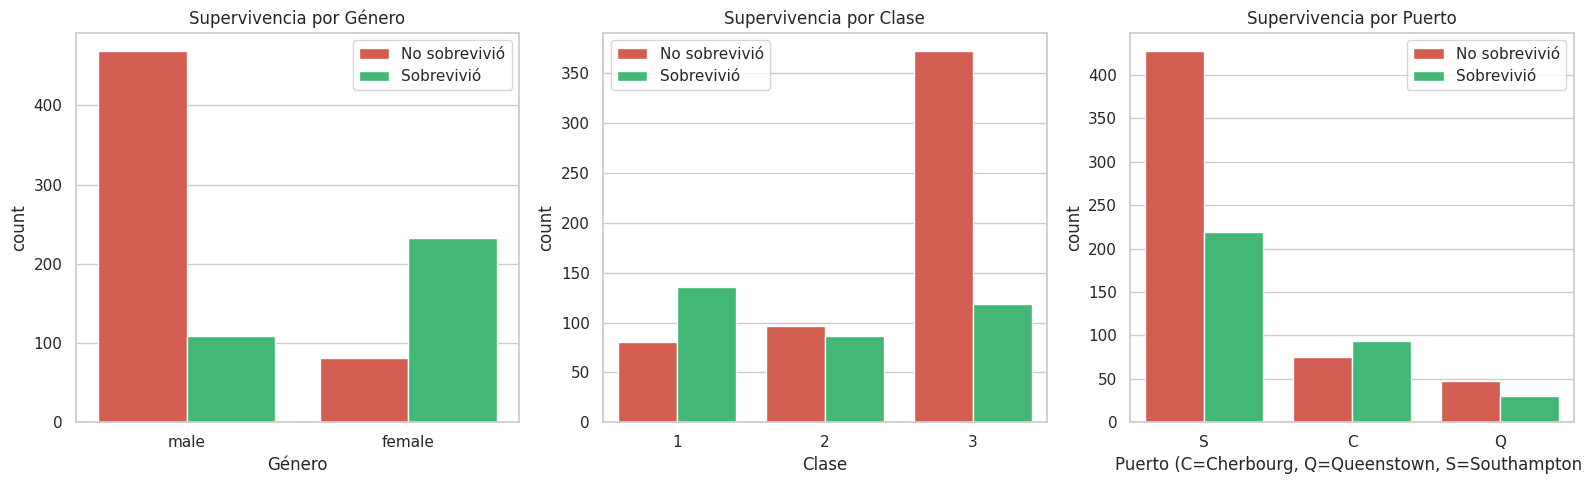

→ Observaciones visibles:
   • Las mujeres sobrevivieron mucho más que los hombres ("mujeres y niños primero")
   • 1ª clase tiene mayor tasa de supervivencia que 3ª


In [13]:
# ─── Gráfico 2: Supervivencia por variables categóricas ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Por género
sns.countplot(data=df_limpio, x='sex', hue='survived', palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Supervivencia por Género', fontsize=12)
axes[0].set_xlabel('Género')
axes[0].legend(['No sobrevivió', 'Sobrevivió'])

# Por clase
sns.countplot(data=df_limpio, x='pclass', hue='survived', palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Supervivencia por Clase', fontsize=12)
axes[1].set_xlabel('Clase')
axes[1].legend(['No sobrevivió', 'Sobrevivió'])

# Por puerto de embarque
sns.countplot(data=df_limpio, x='embarked', hue='survived', palette=['#e74c3c', '#2ecc71'], ax=axes[2])
axes[2].set_title('Supervivencia por Puerto', fontsize=12)
axes[2].set_xlabel('Puerto (C=Cherbourg, Q=Queenstown, S=Southampton)')
axes[2].legend(['No sobrevivió', 'Sobrevivió'])

plt.tight_layout()
plt.show()
print('→ Observaciones visibles:')
print('   • Las mujeres sobrevivieron mucho más que los hombres ("mujeres y niños primero")')
print('   • 1ª clase tiene mayor tasa de supervivencia que 3ª')

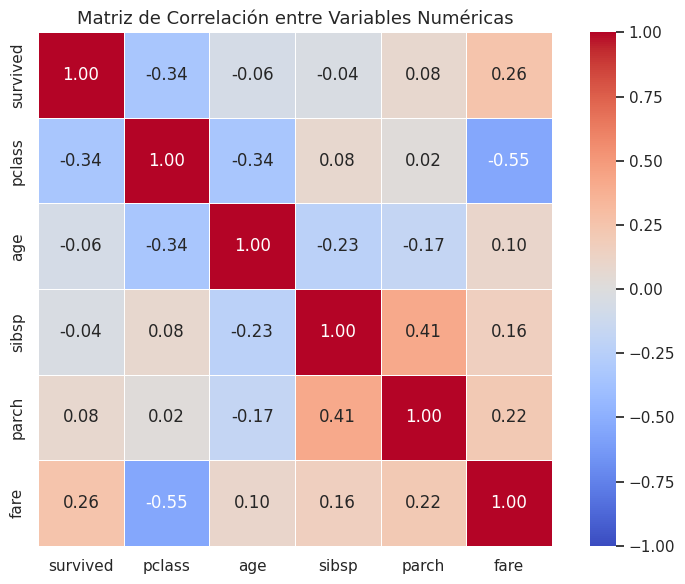

→ Interpretación:
   • pclass tiene correlación NEGATIVA con survived (-0.34): más alta la clase, más sobrevivió
   • fare tiene correlación POSITIVA con survived (0.26): tarifas más altas = más supervivencia
   • Correlación ≠ causalidad. pclass y fare están relacionados entre sí (multicolinealidad)


In [14]:
# ─── Gráfico 3: Matriz de correlaciones ─────────────────────────────────────
# Solo para variables numéricas
cols_numericas = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df_limpio[cols_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # Mostrar valores numéricos
    fmt='.2f',            # 2 decimales
    cmap='coolwarm',      # Rojo=positiva, Azul=negativa
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=13)
plt.tight_layout()
plt.show()
print('→ Interpretación:')
print('   • pclass tiene correlación NEGATIVA con survived (-0.34): más alta la clase, más sobrevivió')
print('   • fare tiene correlación POSITIVA con survived (0.26): tarifas más altas = más supervivencia')
print('   • Correlación ≠ causalidad. pclass y fare están relacionados entre sí (multicolinealidad)')

/tmp/ipykernel_36783/1355067477.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='pclass', y='fare', palette='Set3', ax=axes[1])


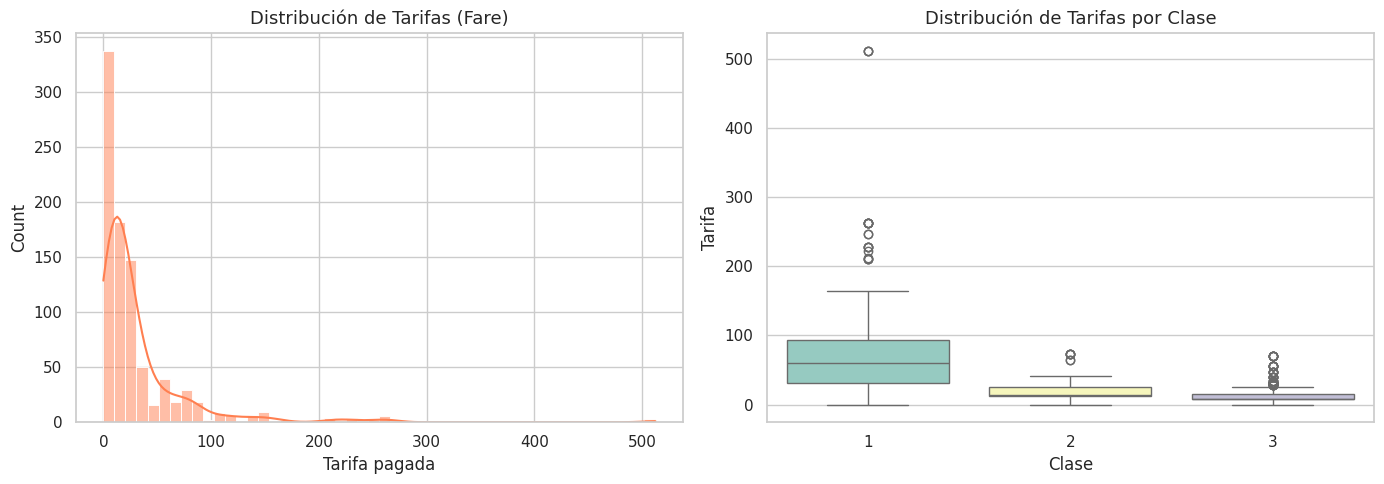

Estadísticas de fare:
   Media:   32.20
   Mediana: 14.45
   Máximo:  512.33

→ La media (32.20) es MUCHO mayor que la mediana (14.45): hay outliers extremos
→ Usar MEDIANA para representar el valor típico de tarifa


In [15]:
# ─── Gráfico 4: Distribución de tarifas (fare) ──────────────────────────────
# Detección visual de outliers con boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de fare (con escala log para ver mejor)
sns.histplot(df_limpio['fare'], bins=50, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Distribución de Tarifas (Fare)', fontsize=13)
axes[0].set_xlabel('Tarifa pagada')

# Boxplot de fare por clase
sns.boxplot(data=df_limpio, x='pclass', y='fare', palette='Set3', ax=axes[1])
axes[1].set_title('Distribución de Tarifas por Clase', fontsize=13)
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Tarifa')

plt.tight_layout()
plt.show()

# Estadísticas de fare
print('Estadísticas de fare:')
print(f'   Media:   {df_limpio["fare"].mean():.2f}')
print(f'   Mediana: {df_limpio["fare"].median():.2f}')
print(f'   Máximo:  {df_limpio["fare"].max():.2f}')
print()
print('→ La media (32.20) es MUCHO mayor que la mediana (14.45): hay outliers extremos')
print('→ Usar MEDIANA para representar el valor típico de tarifa')

---
## ✏️ Actividad Guiada 1 — Análisis de la variable `pclass`

**Instrucciones:** Completá las celdas marcadas con `# TODO:`. Cada celda tiene una pista.

### Consigna
1. Calculá la cantidad y proporción de pasajeros por clase (`pclass`)
2. Construí una **tabla de contingencia** entre `pclass` y `survived`
3. Graficá un `countplot` de `pclass` coloreado por `survived`
4. Respondé: ¿qué clase tiene mayor tasa de supervivencia? ¿Por qué creés que sucede esto?

In [16]:
# ─── TODO 1.1: Distribución de pasajeros por clase ──────────────────────────
# Pista: usá df_limpio['pclass'].value_counts() con normalize=True para ver proporciones

# TODO: calculá la distribución (absoluta y relativa) de la variable pclass

tabla = df_limpio['pclass'].value_counts().to_frame(name='Cantidad')
tabla['Proporción'] = df_limpio['pclass'].value_counts(normalize=True)
tabla['Proporción'] = tabla['Proporción'].round(3)

tabla.reset_index(inplace=True)
tabla.columns = ['Clase (pclass)', 'Cantidad', 'Proporción']

tabla



,Clase (pclass),Cantidad,Proporción
0,3,491,0.551
1,1,216,0.242
2,2,184,0.207


Descripción:
La tabla muestra cómo se distribuyen los pasajeros según su clase (pclass), indicando cuántos hay en cada clase (Cantidad) y qué proporción representan del total (Proporción).

Se observa que la mayoría de los pasajeros pertenece a la clase 3, seguida por la clase 1 y luego la clase 2.

In [27]:
# ─── TODO 1.2: Tabla de contingencia pclass × survived ─────────────────────
# Pista: pd.crosstab(df_limpio['pclass'], df_limpio['survived'])
# Para proporciones: agregá normalize='index'

# TODO: construí la tabla de contingencia con proporciones por fila

tabla_contingencia = pd.crosstab(df_limpio['pclass'], df_limpio['survived'], normalize='index')
tabla_contingencia


survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


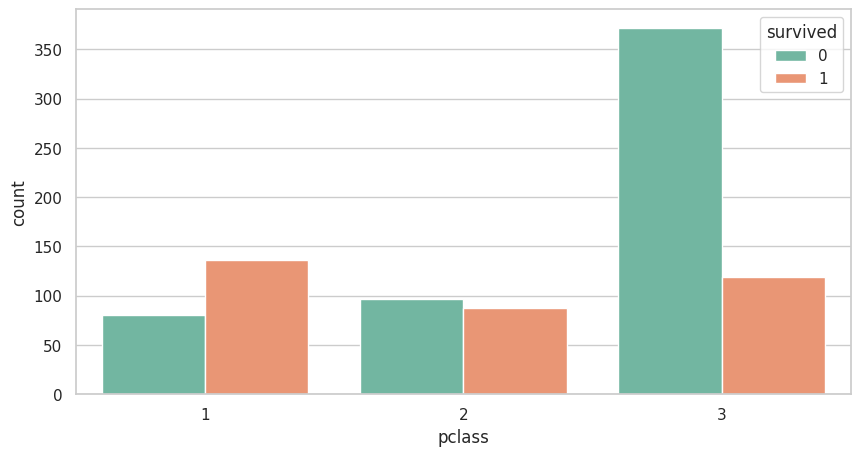

In [28]:
# ─── TODO 1.3: Countplot de pclass por survived ─────────────────────────────
# Pista: usá sns.countplot(data=df_limpio, x='pclass', hue='survived')

# TODO: graficá el countplot

sns.countplot(data=df_limpio, x='pclass', hue='survived')
plt.show()


**Respondé en esta celda (doble click para editar):**

¿Qué clase tiene mayor tasa de supervivencia? ¿A qué atribuís ese resultado?

*Tu respuesta:* La clase 1 es la que tiene mayor tasa de supervivencia. Esto se debe probablemente a que los pasajeros de primera clase tenían mejores condiciones y mayor prioridad en el acceso a los botes salvavidas.

## ✏️ Actividad Guiada 2 — Detección de Outliers en `fare`

Un **outlier** es un valor que se aleja considerablemente del resto de los datos.  
Un método sencillo es el **criterio IQR** (Rango Intercuartílico):

```
Q1 = percentil 25    Q3 = percentil 75    IQR = Q3 - Q1
Límite inferior = Q1 - 1.5 × IQR
Límite superior = Q3 + 1.5 × IQR
```

Valores fuera de ese rango se consideran outliers.

### Consigna
1. Calculá Q1, Q3 e IQR para la variable `fare`
2. Determiná los límites inferior y superior
3. Contá cuántos outliers hay

In [29]:
# ─── TODO 2.1: Calculá IQR y límites de outliers para 'fare' ────────────────
# Pista: Q1 = df_limpio['fare'].quantile(0.25)
#        Q3 = df_limpio['fare'].quantile(0.75)
#        IQR = Q3 - Q1

# TODO: calculá Q1, Q3, IQR y los límites


# TODO: contá cuántos valores de 'fare' están por encima del límite superior

Q1 = df_limpio['fare'].quantile(0.25)
Q3 = df_limpio['fare'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_limpio[df_limpio['fare'] > limite_superior]

len(outliers)


116

In [20]:
# ─── SOLUCIÓN DE REFERENCIA (ejecutar después de intentarlo) ────────────────
# Descomentá para ver la solución

# Q1 = df_limpio['fare'].quantile(0.25)
# Q3 = df_limpio['fare'].quantile(0.75)
# IQR = Q3 - Q1
# limite_inferior = Q1 - 1.5 * IQR
# limite_superior = Q3 + 1.5 * IQR
# outliers = df_limpio[(df_limpio['fare'] < limite_inferior) | (df_limpio['fare'] > limite_superior)]
# print(f'Q1: {Q1:.2f}  |  Q3: {Q3:.2f}  |  IQR: {IQR:.2f}')
# print(f'Límite inferior: {limite_inferior:.2f}')
# print(f'Límite superior: {limite_superior:.2f}')
# print(f'Cantidad de outliers: {len(outliers)} ({len(outliers)/len(df_limpio)*100:.1f}%)')

---
## 🏆 Actividad Autónoma — EDA Completo de un Nuevo Dataset

> **Para entregar:** Notebook completado subido al aula virtual antes del inicio de la próxima clase.

### Instrucciones

Elegí **UNO** de estos datasets y realizá un EDA completo:

```python
df2 = sns.load_dataset('tips')     # Propinas en restaurante
df2 = sns.load_dataset('penguins') # Pingüinos de 3 especies  
df2 = sns.load_dataset('diamonds') # Precios de diamantes
```

### Tu análisis debe incluir:

1. ✅ **Carga y dimensiones** — `head()`, `shape`, `info()`
2. ✅ **Estadística descriptiva** — `describe(include='all')`
3. ✅ **Análisis de faltantes** — tabla de faltantes y decisión de tratamiento
4. ✅ **Al menos 3 visualizaciones** apropiadas para el tipo de variable
5. ✅ **Mínimo 3 conclusiones** redactadas en celdas Markdown
6. ✅ **Código comentado** en castellano explicando cada bloque

### Criterios de evaluación

| Criterio | Puntaje |
|----------|--------|
| Corrección y funcionalidad del código | 30% |
| Calidad del análisis y justificación de decisiones | 30% |
| Visualizaciones pertinentes y bien etiquetadas | 20% |
| Conclusiones claras y fundamentadas | 20% |

---

In [31]:
# ─── ZONA DE TRABAJO — ACTIVIDAD AUTÓNOMA ───────────────────────────────────
# Cargá el dataset que elegiste

# TODO: cargar el dataset
# df2 = sns.load_dataset('???')

df2 = sns.load_dataset('tips')



In [32]:
# TODO: exploración inicial — head, info, describe

df2.head()
df2.shape
df2.info()
df2.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


In [33]:
# TODO: análisis de valores faltantes

df2.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


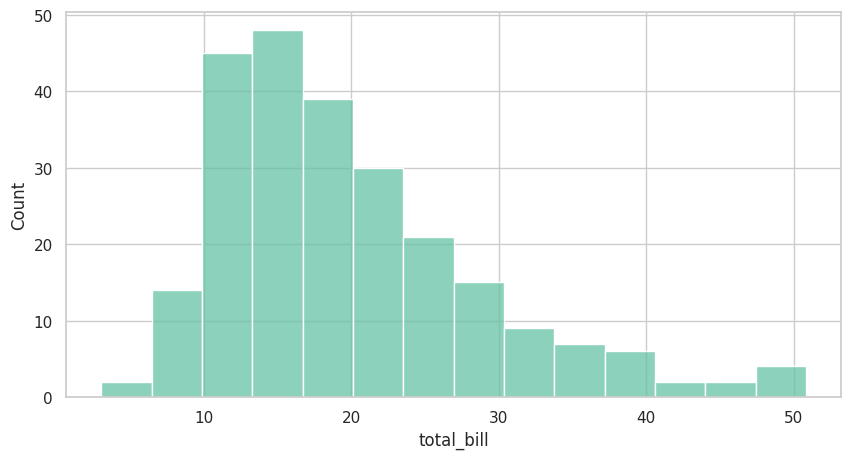

In [34]:
# TODO: visualización 1

sns.histplot(data=df2, x='total_bill')
plt.show()


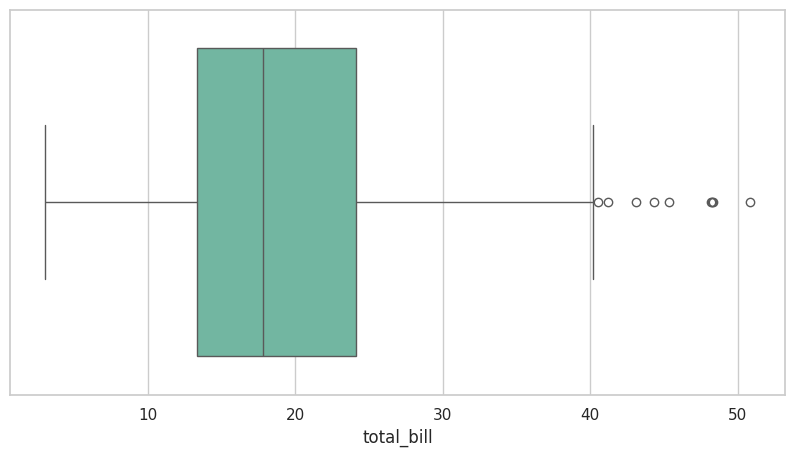

In [35]:
# TODO: visualización 2

sns.boxplot(data=df2, x='total_bill')
plt.show()

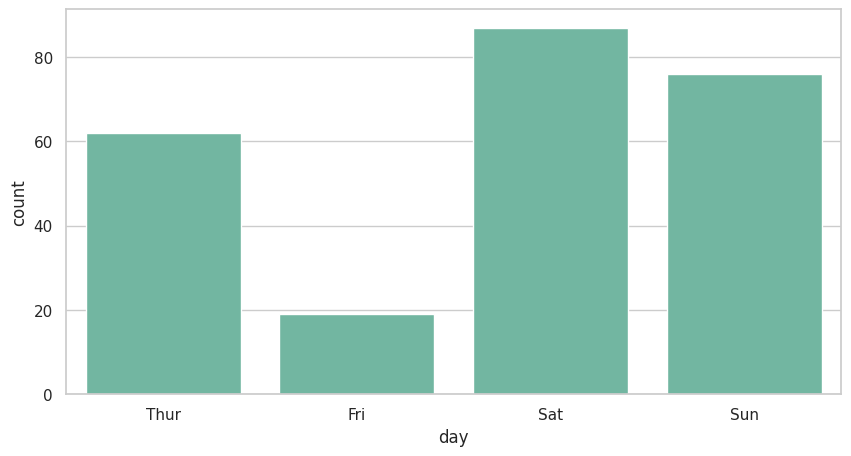

In [36]:
# TODO: visualización 3
sns.countplot(data=df2, x='day')
plt.show()


### 📝 Conclusiones

**Conclusión 1:** La mayoría de las cuentas totales se concentran en valores medios, con algunos valores altos (outliers).

**Conclusión 2:** Existen valores atípicos en total_bill, lo que indica cuentas significativamente más altas que el promedio.

**Conclusión 3:** El día con mayor cantidad de registros es sábado, seguido por domingo, lo que muestra mayor actividad el fin de semana.

---
## 📋 Resumen — Lo que aprendimos hoy

| Paso | Qué hicimos | Comandos clave |
|------|-------------|----------------|
| 1 | Configurar entorno | `import pandas, numpy, matplotlib, seaborn` |
| 2 | Cargar dataset | `sns.load_dataset()`, `pd.read_csv()` |
| 3 | Exploración inicial | `head()`, `info()`, `describe()`, `isnull().sum()`, `value_counts()` |
| 4 | Tipos de variables | `select_dtypes()` |
| 5 | Tratar faltantes | `fillna()`, `dropna()`, `drop()` |
| 6 | Visualizar | `histplot()`, `countplot()`, `boxplot()`, `heatmap()` |

### ¿Dónde encaja esto en KDD y CRISP-DM?

```
KDD:      Selección ✅ | Preprocesamiento ✅ | Transformación → | Minería → | Evaluación →
CRISP-DM: Negocio ✅ | Comprensión datos ✅ | Preparación ✅ | Modelado → | Evaluación → | Deploy →
```

---

## 🔜 Próxima clase

**Clase 3 (Teórica) — Preprocesamiento Avanzado:**
- Codificación de variables categóricas (`LabelEncoder`, `OneHotEncoder`)
- Normalización y estandarización (`MinMaxScaler`, `StandardScaler`)
- Pipeline de scikit-learn
- División train/test

**Para preparar:**  
📖 Leer sobre Feature Engineering (link en el aula virtual)  
📦 En Colab ya tenés scikit-learn disponible. Si trabajás local: `pip install scikit-learn`

---
*Politécnico Malvinas Argentinas | Tecnicatura en Informática | Minería de Datos 2026*